### Return Periods


Code compiled from skramer and clee


### Return Period Calculation “Rank Method” (a.k.a. Weibull plotting-position method)

**Procedure**
1. Collect all storm maximum wind speeds (qualifying radius + threshold)  
2. Sort them from largest → smallest  
3. Assign each value a rank r = 1, 2, 3, ...  
4. Apply a plotting-position formula: RP(r) = (n + 1) / r  
    * n = total number of qualifying storms  
    * r = 1 is the strongest storm (small RP)  
    * r = n is the weakest storm (large RP)  
5. Frequency of Exceedance (FoE) is the inverse: FoE(r) = 1 / RP(r)

**Properties**
1. Simple and non-parametric  
2. Preserves the shape of each ensemble curve exactly  
3. Used for per-ensemble RP curves and ensemble-mean RP curves after interpolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import sys
import os, glob
import xarray as xr


## most correct would probably be to seperate this... 
### get variables from chaz run
import Namelist as gv


In [2]:
# Historical RP/FoE + Tracks Pipeline (ERA5, ERA-Interim)
# -------------------------------------------------------
# This script computes pooled-catalog (aggregate) Return Period (RP) and Frequency of
# Exceedance (FoE) curves for DoD bases using:
#   • ERA5 (1950–2020) 
#   • ERA-Interim (1950–2020)
# It also loads observed IBTrACS-based curves from /home/skramer/DOD/IBTrACS
# to perform a single-point calibration at a chosen wind threshold (default
# controlled by the caller - 40kt ). The adjusted FoE/RP curves are saved alongside
# the original model curves in per-base, per-model .npz files.

import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# =====================================
# Bases of Interest (lon in 0–360°E)
# =====================================
# NOTE: Longitudes are 0–360°E. Convert negative longitudes by adding 360.
dod_boi = {
    "Naval Station Norfolk (Virginia, USA)": (283.313, 36.945),
    "Naval Air Station Oceana / Dam Neck Annex (Virginia, USA)": (283.033, 36.816),
    "Naval Construction Battalion Center Gulfport (Mississippi, USA)": (270.908, 30.367),
    "Keesler Air Force Base (Mississippi, USA)": (271.076, 30.410),
    "Naval Air Station Key West (Florida, USA)": (278.681, 24.575),
    "Tyndall Air Force Base (Florida, USA)": (274.424, 30.069),
    "Naval Base Guam (Apra Harbor, Guam)": (144.656, 13.444),
    "Andersen Air Force Base (Guam)": (144.926, 13.584),
    "Camp Smedley D. Butler (Okinawa, Japan)": (127.800, 26.300),
    "Kadena Air Base (Okinawa, Japan)": (127.769, 26.355),
    "Camp Schwab (Okinawa, Japan)": (127.769, 26.355),
}

# ======================
# Model configurations
# ======================
# Each model entry defines where to find CHAZ-style storm catalogs and where
# to save outputs. "file_pattern" should match the per-storm NetCDF files.
model_configs = {
    "ERA5-Original-CHAZ": {
        "base_dir": "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/",
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "global_2019_2ens*_pre.nc",
        "year_range": (2000, 2009),
        "output_dir": f"{gv.output_path}ReturnPeriods/",
        "name": "ERA5-Original-CHAZ"
    },
    "ERA5-Updated-CHAZ": {
        "base_dir": gv.output_path,
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "ERA5_*_ens0*.nc",
        "year_range": (2000, 2009),
        "output_dir": f"{gv.output_path}ReturnPeriods/",
        "name": "ERA5-Updated-CHAZ"
    },
}

# ==================================================
# Save per-base arrays (RP/FoE) to a single NPZ file
# ==================================================

def _sanitize(name: str) -> str:
    """Return a filesystem-safe version of a base name."""
    return ''.join(ch if ch.isalnum() or ch in ('_', '-') else '_' for ch in name)


def save_base_model_results_single(
    base_name,
    model_key,
    return_periods,
    wind_speeds,
    foe,
    output_dir,
    *,
    adjusted_return_periods=None,
    adjusted_foe=None,
    adjustment_factor=None,
    foe_at_threshold=None,
    observed_foe_at_threshold=None,
    calibration_threshold=None,
):
    """Save a single NPZ per base *per model* in the model's output folder.

    Filenames include a short model tag (ERA5 or ERAI), e.g.:
      /home/skramer/DOD/CHAZ-ERA/ERA5/return_period_curves_ERA5_<BASE>.npz
      /home/skramer/DOD/CHAZ-ERA/ERA-Interim/return_period_curves_ERAI_<BASE>.npz

    Stored fields (always present):
      - return_periods: 1D array (years)
      - wind_speeds:   1D array (kt, sorted descending)
      - foe:           1D array (1/years)
      - model:         str (model key)
      - base_name:     str (human-readable base)

    Stored fields (present when calibration was possible):
      - calibration_threshold: float (kt)
      - adjustment_factor:     float (observed_FoE/ model_FoE at threshold)
      - foe_at_threshold:      float (model FoE at threshold)
      - observed_foe_at_threshold: float
      - adjusted_return_periods: 1D array (years)
      - adjusted_foe:            1D array (1/years)
    """
    os.makedirs(output_dir, exist_ok=True)
    safe_name = _sanitize(base_name)

    key_upper = str(model_key).upper()
    if key_upper.startswith("ERA5"):
        tag = "ERA5"
    elif "INTERIM" in key_upper:
        tag = "ERAI"
    else:
        tag = key_upper.replace(" ", "_")

    filename = os.path.join(output_dir, f"return_period_curves_{tag}_{safe_name}.npz")

    np.savez(
        filename,
        # original
        return_periods=return_periods,
        wind_speeds=wind_speeds,
        foe=foe,
        model=model_key,
        base_name=base_name,
        # calibration meta and adjusted curves
        calibration_threshold=calibration_threshold,
        adjustment_factor=adjustment_factor,
        foe_at_threshold=foe_at_threshold,
        observed_foe_at_threshold=observed_foe_at_threshold,
        adjusted_return_periods=adjusted_return_periods,
        adjusted_foe=adjusted_foe,
    )
    print(f"Saved {model_key} results to {filename}")


def compute_rp_and_foe(wind_speeds, num_years):
    """Compute empirical RP and FoE given per-storm maxima and catalog years.

    Parameters
    ----------
    wind_speeds : 1D array
        Max wind (kt) per qualifying storm (one value per storm).
    num_years : int
        Effective catalog years used for frequency scaling (e.g., years per
        file × number of files in pooled catalog).

    Returns
    -------
    return_periods : 1D array (years)
    foe            : 1D array (1/years)
    sorted_ws      : 1D array (kt, sorted descending)
    """
    sorted_ws = np.sort(wind_speeds)[::-1]
    ranks = np.arange(1, len(sorted_ws) + 1)
    return_periods = num_years / ranks
    foe = 1.0 / return_periods
    return return_periods, foe, sorted_ws

# ==========================================
# Storm extraction from NetCDF catalogs
# ==========================================

def extract_combined_winds(
    base_dir,
    ensemble_dirs,
    sub_dir,
    file_pattern,
    lon_poi,
    lat_poi,
    radius_km,
    threshold_knots,
    year_range,
    model_key=None,
    files_override=None,
):
    """Collect max in-radius winds for storms satisfying spatial/intensity filters.

    DATA FLOW OVERVIEW
    ------------------
    1) **Enumerate files**: Build a list of NetCDF catalog files by joining
       `base_dir` / each `ensemble_dir` / optional `sub_dir`, filtered by
       `file_pattern`. If `files_override` is provided, use it directly.

    2) **Read per-file variables**: For each file, open with xarray and read
       the expected CHAZ-style variables:
         - `Mwspd`     → wind speed [time, storm, (optional) ensembleNum]
         - `longitude` → lon        [time, storm, (optional) ensembleNum]
         - `latitude`  → lat        [time, storm, (optional) ensembleNum]
         - `year`      → per-storm year (optional) [storm]
       If an `ensembleNum` dimension is present, we select the first member
       (`isel(ensembleNum=0)`) to reduce to [time, storm].

    3) **Clean / normalize**: Replace CHAZ fill values (-9999) with NaN, and
       coerce longitudes into 0–360°E by adding 360 where lon < 0.

    4) **Filter by year (optional)**: If a per-storm `year` vector exists,
       drop storms whose year is outside `year_range` (inclusive).

    5) **Compute distances**: For each remaining storm, compute great-circle
       approximations (flat-Earth) from the base of interest (lon_poi, lat_poi)
       to each storm time step:
           dx = (km per deg lon at that lat) * lon_diff
           dy = 110 km/deg * lat_diff
           dist = sqrt(dx^2 + dy^2)
       where km-per-degree of longitude uses cos(latitude) scaling.

    6) **Select in-radius & threshold**: Mark time steps with `dist <= radius_km`.
       A storm is *kept* if ANY in-radius timestep has wind ≥ `threshold_knots`.
       For kept storms, record the **maximum wind while in-radius**. This yields
       one scalar per storm.

    Returns
    -------
    1D numpy array of max in-radius winds (kt) for all qualifying storms across
    all files.
    """
    all_storms = []  # list of per-storm maxima (kt)

    # 1) Enumerate files
    if files_override is not None:
        file_lists = [files_override]
    else:
        file_lists = []
        for ens in ensemble_dirs:
            # Construct path to ensemble subdir, honoring optional nested sub_dir
            ens_dir = os.path.join(base_dir, ens, sub_dir) if sub_dir != "." else os.path.join(base_dir, ens)
            file_lists.append(glob.glob(os.path.join(ens_dir, file_pattern)))

    # 2) Iterate over files and read variables
    for files in file_lists:
        for f in files:
            ds = xr.open_dataset(f)
            if "Mwspd" not in ds:
                # Skip files without winds
                continue

            # Winds (drop ensemble dimension if present)
            w_da = ds["Mwspd"]
            if "ensembleNum" in w_da.dims:
                w_da = w_da.isel(ensembleNum=0)
            wspd = w_da.values  # shape: [time, storm]

            # Coordinates (drop ensemble dimension if present)
            lon_da = ds["longitude"]
            lat_da = ds["latitude"]
            if "ensembleNum" in lon_da.dims:
                lon_da = lon_da.isel(ensembleNum=0)
                lat_da = lat_da.isel(ensembleNum=0)
            lon = lon_da.values  # [time, storm]
            lat = lat_da.values  # [time, storm]

            # Optional per-storm year
            years = ds["year"].values if "year" in ds else None  # [storm]

            # 3) Clean / normalize values
            lon = np.where(lon == -9999, np.nan, lon)
            lat = np.where(lat == -9999, np.nan, lat)
            wspd = np.where(wspd == -9999, np.nan, wspd)
            lon[lon < 0] += 360  # force 0–360°E

            # 4–6) Loop storms to filter and compute in-radius maxima
            n_storm = wspd.shape[1]
            for i in range(n_storm):
                # (4) Year filter (if available)
                if years is not None:
                    y = years[i]
                    if not (year_range[0] <= y <= year_range[1]):
                        continue

                # (5) Distance (km) at each timestep using flat-Earth approx
                km_per_deg_lon = 2 * np.pi * 6371.0 * np.cos(np.radians(lat[:, i])) / 360.0
                dx = km_per_deg_lon * (lon[:, i] - lon_poi)
                dy = 110.0 * (lat[:, i] - lat_poi)
                dist = np.sqrt(dx**2 + dy**2)
                in_radius = dist <= radius_km

                # (6) Check radius+threshold and record in-radius max wind
                if np.any(in_radius & (wspd[:, i] >= threshold_knots)):
                    all_storms.append(np.nanmax(wspd[in_radius, i]))

    return np.array(all_storms)

# # ============================================================
# # RP/FoE plotting for a given base and list of model keys
# # ============================================================

# def plot_return_periods_and_foe(
#     models_to_plot,
#     base_name,
#     radius_km,
#     threshold_knots,
#     override_year_range=None,
#     configs=None,
# ):
#     """Compute, calibrate (if possible), plot, and save curves for a base.

#     Loads observed curves strictly from /home/skramer/DOD/IBTrACS/ and, when
#     available, performs a single-point calibration that matches model FoE to
#     observed FoE at the requested wind threshold.
#     """
#     if configs is None:
#         configs = model_configs

#     lon_poi, lat_poi = dod_boi[base_name]

#     # --- Load observed once (used for plotting and calibration) ---
#     safe = _sanitize(base_name)
#     obs_path = os.path.join("/home/skramer/DOD/IBTrACS", f"observed_return_periods_{safe}.npz")
#     obs_available = os.path.exists(obs_path)
#     obs_rp = obs_ws = obs_foe = None
#     obs_foe_at_thresh = None
#     if obs_available:
#         obs = np.load(obs_path, allow_pickle=True)
#         obs_rp = obs['return_periods']
#         obs_ws = obs['wind_speeds']
#         # Prefer saved scalar, otherwise interpolate from arrays
#         obs_foe = obs['frequency_of_exceedance'] if 'frequency_of_exceedance' in obs.files else None
#         if 'foe_at_threshold' in obs.files and np.isfinite(obs['foe_at_threshold']):
#             try:
#                 obs_foe_at_thresh = float(obs['foe_at_threshold'])
#             except Exception:
#                 obs_foe_at_thresh = None
#         if obs_foe_at_thresh is None and obs_foe is not None:
#             obs_foe_at_thresh = float(np.interp(threshold_knots, obs_ws[::-1], obs_foe[::-1]))
#         print(f"Loaded observed file: {obs_path}")
#     else:
#         print(f"Observed file not found in /home/skramer/DOD/IBTrACS for key: {safe}")

#     # --- Plot RP curves and save (with adjusted curves when possible) ---
#     for model_key in models_to_plot:
#         cfg = configs[model_key]
#         year_range = override_year_range if (override_year_range is not None) else cfg['year_range']

#         winds = extract_combined_winds(
#             cfg['base_dir'], cfg['ensemble_dirs'], cfg.get('sub_dir', '.'), cfg['file_pattern'],
#             lon_poi, lat_poi, radius_km, threshold_knots, year_range, model_key
#         )
#         if winds.size == 0:
#             print(f"No storms found for {model_key} at {base_name}.")
#             continue

#         # Count of catalogs to scale RP denominator (pooled)
#         files = []
#         for ens in cfg['ensemble_dirs']:
#             ens_dir = os.path.join(
#                 cfg['base_dir'], ens, cfg.get('sub_dir', '.')
#             ) if cfg.get('sub_dir', '.') != '.' else os.path.join(cfg['base_dir'], ens)
#             files.extend(glob.glob(os.path.join(ens_dir, cfg['file_pattern'])))
#         num_years = (year_range[1] - year_range[0] + 1) * (len(files) if files else len(cfg['ensemble_dirs']))

#         rp, foe, sorted_ws = compute_rp_and_foe(winds, num_years)

#         # --- Adjustment using observed FoE at threshold (if available) ---
#         adj_factor = None
#         foe_at_thresh = None
#         adjusted_rp = None
#         adjusted_foe = None
#         if obs_available and obs_foe_at_thresh is not None and np.isfinite(obs_foe_at_thresh):
#             foe_at_thresh = float(np.interp(threshold_knots, sorted_ws[::-1], foe[::-1]))
#             if foe_at_thresh > 0 and np.isfinite(foe_at_thresh):
#                 adj_factor = float(obs_foe_at_thresh / foe_at_thresh)
#                 adjusted_foe = foe * adj_factor
#                 adjusted_rp = 1.0 / adjusted_foe

#         # --- Per-model figure: plot observed, original RP, and adjusted RP (if available) ---
#         plt.figure(figsize=(8, 6))
#         if obs_available:
#             plt.plot(obs_rp, obs_ws, color='black', lw=2.8, label='Observed')
#         # Original model RP
#         plt.plot(rp, sorted_ws, linestyle='--', linewidth=2.0, label=f"{model_key} (orig)")
#         # Adjusted model RP, if computed
#         if adjusted_rp is not None:
#             plt.plot(adjusted_rp, sorted_ws, linewidth=2.5, label=f"{model_key} (adj)")

#         # Save including adjusted arrays when available
#         save_base_model_results_single(
#             base_name,
#             model_key,
#             rp,
#             sorted_ws,
#             foe,
#             cfg['output_dir'],
#             adjusted_return_periods=adjusted_rp,
#             adjusted_foe=adjusted_foe,
#             adjustment_factor=adj_factor,
#             foe_at_threshold=foe_at_thresh,
#             observed_foe_at_threshold=obs_foe_at_thresh,
#             calibration_threshold=threshold_knots,
#         )

#         plt.xscale('log')
#         plt.xlabel('Return Period (years)')
#         plt.ylabel('Wind Speed (knots)')
#         plt.title(f'Return Periods — {base_name} — {model_key}')
#         plt.legend(fontsize=8)
#         plt.grid(True, alpha=0.4)
#         plt.tight_layout()
#         plt.show()

def plot_return_periods_and_foe(
    models_to_plot,
    base_name,
    radius_km,
    threshold_knots,
    override_year_range=None,
    configs=None,
):
    """Compute, calibrate, plot, and save curves for a base.

    All requested models are plotted on the SAME figure.

    For each model:
      - dashed line = original model RP curve
      - solid line = calibrated/adjusted model RP curve
      - observed curve = black
    """
    if configs is None:
        configs = model_configs

    lon_poi, lat_poi = dod_boi[base_name]

    # --------------------------------------------------
    # Load observed once
    # --------------------------------------------------
    safe = _sanitize(base_name)
    obs_path = os.path.join(
        "/home/skramer/DOD/IBTrACS",
        f"observed_return_periods_{safe}.npz"
    )

    obs_available = os.path.exists(obs_path)
    obs_rp = obs_ws = obs_foe = None
    obs_foe_at_thresh = None

    if obs_available:
        obs = np.load(obs_path, allow_pickle=True)

        obs_rp = obs["return_periods"]
        obs_ws = obs["wind_speeds"]

        obs_foe = (
            obs["frequency_of_exceedance"]
            if "frequency_of_exceedance" in obs.files
            else None
        )

        # Prefer saved scalar calibration value
        if (
            "foe_at_threshold" in obs.files
            and np.isfinite(obs["foe_at_threshold"])
        ):
            try:
                obs_foe_at_thresh = float(obs["foe_at_threshold"])
            except Exception:
                obs_foe_at_thresh = None

        # Otherwise interpolate from observed curve
        if obs_foe_at_thresh is None and obs_foe is not None:
            obs_foe_at_thresh = float(
                np.interp(
                    threshold_knots,
                    obs_ws[::-1],
                    obs_foe[::-1]
                )
            )

        print(f"Loaded observed file: {obs_path}")

    else:
        print(
            f"Observed file not found in /home/skramer/DOD/IBTrACS "
            f"for key: {safe}"
        )

    # ==================================================
    # CREATE ONE FIGURE FOR ALL MODELS
    # ==================================================
    fig, ax = plt.subplots(figsize=(9, 7))

    # Plot observed only once
    if obs_available:
        ax.plot(
            obs_rp,
            obs_ws,
            color="black",
            lw=2.8,
            label="Observed"
        )

    # Choose distinct colors for models
    colors = plt.cm.tab10(np.linspace(0, 1, len(models_to_plot)))

    # --------------------------------------------------
    # Loop over models
    # --------------------------------------------------
    for color, model_key in zip(colors, models_to_plot):

        cfg = configs[model_key]

        year_range = (
            override_year_range
            if override_year_range is not None
            else cfg["year_range"]
        )

        # ----------------------------------------------
        # Extract storms
        # ----------------------------------------------
        winds = extract_combined_winds(
            cfg["base_dir"],
            cfg["ensemble_dirs"],
            cfg.get("sub_dir", "."),
            cfg["file_pattern"],
            lon_poi,
            lat_poi,
            radius_km,
            threshold_knots,
            year_range,
            model_key
        )

        if winds.size == 0:
            print(f"No storms found for {model_key} at {base_name}.")
            continue

        # ----------------------------------------------
        # Count catalog years
        # ----------------------------------------------
        files = []

        for ens in cfg["ensemble_dirs"]:
            ens_dir = (
                os.path.join(
                    cfg["base_dir"],
                    ens,
                    cfg.get("sub_dir", ".")
                )
                if cfg.get("sub_dir", ".") != "."
                else os.path.join(cfg["base_dir"], ens)
            )

            files.extend(
                glob.glob(
                    os.path.join(
                        ens_dir,
                        cfg["file_pattern"]
                    )
                )
            )
        if cfg['name'] == 'ERA5-Original-CHAZ':
            num_years = (
                (year_range[1] - year_range[0] + 1)
                * (
                    len(files)
                    if files
                    else len(cfg["ensemble_dirs"])
                )
            )
        elif cfg['name'] == 'ERA5-Updated-CHAZ':
            num_years = len(files)
            
        else:
            raise ValueError(f"Unknown configuration: {name}")


        # ----------------------------------------------
        # Compute RP / FoE
        # ----------------------------------------------
        rp, foe, sorted_ws = compute_rp_and_foe(
            winds,
            num_years
        )

        # ----------------------------------------------
        # Calibration using observed FoE
        # ----------------------------------------------
        adj_factor = None
        foe_at_thresh = None
        adjusted_rp = None
        adjusted_foe = None

        if (
            obs_available
            and obs_foe_at_thresh is not None
            and np.isfinite(obs_foe_at_thresh)
        ):

            foe_at_thresh = float(
                np.interp(
                    threshold_knots,
                    sorted_ws[::-1],
                    foe[::-1]
                )
            )

            if foe_at_thresh > 0 and np.isfinite(foe_at_thresh):

                adj_factor = float(
                    obs_foe_at_thresh / foe_at_thresh
                )

                adjusted_foe = foe * adj_factor
                adjusted_rp = 1.0 / adjusted_foe

        # ==================================================
        # Plot original
        # ==================================================
        ax.plot(
            rp,
            sorted_ws,
            linestyle="--",
            linewidth=2.0,
            color=color,
            label = f"{model_key}"
            #label=f"{model_key} (orig)"
        )

        # ==================================================
        # Plot adjusted
        # ==================================================
        if adjusted_rp is not None:
            ax.plot(
                adjusted_rp,
                sorted_ws,
                linestyle="-",
                linewidth=2.5,
                color=color,
                label=f"{model_key} (adj)"
            )

        # ----------------------------------------------
        # Save model results
        # ----------------------------------------------
        save_base_model_results_single(
            base_name,
            model_key,
            rp,
            sorted_ws,
            foe,
            cfg["output_dir"],
            adjusted_return_periods=adjusted_rp,
            adjusted_foe=adjusted_foe,
            adjustment_factor=adj_factor,
            foe_at_threshold=foe_at_thresh,
            observed_foe_at_threshold=obs_foe_at_thresh,
            calibration_threshold=threshold_knots,
        )

    # ==================================================
    # Format figure
    # ==================================================
    ax.set_xscale("log")

    ax.set_xlabel("Return Period (years)")
    ax.set_ylabel("Wind Speed (knots)")

    ax.set_title(
        f"Return Periods — {base_name}\n"
        f"Threshold ≥ {threshold_knots} kt, "
        f"Radius = {radius_km} km"
    )

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

    fig.tight_layout()
    plt.show()


# =========================================
# Optional: Map plotting of qualifying tracks
# =========================================
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    _HAS_CARTOPY = True
except Exception:
    print("Cartopy not available; will use plain lon/lat plots.")
    _HAS_CARTOPY = False


def _choose_extent_for_base(lon_poi):
    if 100 <= lon_poi <= 180:
        return [100, 180], [0, 35]    # WNP
    elif 180 < lon_poi <= 250:
        return [180, 250], [0, 35]    # CP
    else:
        return [260, 360], [0, 45]    # ATL/GOM/Carib


def _collect_qualifying_tracks(base_dir, ensemble_dirs, sub_dir, file_pattern,
                               lon_poi, lat_poi, radius_km, threshold_knots,
                               year_range, files_override=None):
    tracks = []

    if files_override is None:
        file_lists = []
        for ens in ensemble_dirs:
            ens_dir = os.path.join(base_dir, ens, sub_dir) if sub_dir != "." else os.path.join(base_dir, ens)
            file_lists.append(glob.glob(os.path.join(ens_dir, file_pattern)))
    else:
        file_lists = [files_override]

    for files in file_lists:
        for f in files:
            ds = xr.open_dataset(f)
            if "Mwspd" not in ds:
                continue

            w_da = ds["Mwspd"]
            if "ensembleNum" in w_da.dims:
                w_da = w_da.isel(ensembleNum=0)
            wspd = w_da.values

            lon_da = ds["longitude"]; lat_da = ds["latitude"]
            if "ensembleNum" in lon_da.dims:
                lon_da = lon_da.isel(ensembleNum=0)
                lat_da = lat_da.isel(ensembleNum=0)
            lon = lon_da.values; lat = lat_da.values

            years = ds["year"].values if "year" in ds else None

            lon = np.where(lon == -9999, np.nan, lon)
            lat = np.where(lat == -9999, np.nan, lat)
            wspd = np.where(wspd == -9999, np.nan, wspd)
            lon[lon < 0] += 360

            n_storm = wspd.shape[1]
            for i in range(n_storm):
                if years is not None:
                    y = years[i]
                    if not (year_range[0] <= y <= year_range[1]):
                        continue

                dx = 2 * np.pi * 6371.0 * np.cos(np.radians(lat[:, i])) / 360 * (lon[:, i] - lon_poi)
                dy = 110.0 * (lat[:, i] - lat_poi)
                dist = np.sqrt(dx ** 2 + dy ** 2)
                in_radius = dist <= radius_km

                if np.any(in_radius & (wspd[:, i] >= threshold_knots)):
                    valid = ~np.isnan(lon[:, i]) & ~np.isnan(lat[:, i]) & ~np.isnan(wspd[:, i])
                    if np.any(valid):
                        tracks.append((lon[valid, i], lat[valid, i], wspd[valid, i]))
    return tracks


def plot_model_tracks(models_to_plot, base_name, radius_km, threshold_knots,
                      override_year_range=None, configs=None):
    """Plot one map **per model** showing qualifying tracks for the given base.

    For each model in `models_to_plot`, gathers tracks that met the radius
    + threshold filters and generates its own figure (so you get two plots per
    base when using ["ERA5", "ERA-INTERIM"]).
    """
    if configs is None:
        configs = model_configs

    lon_poi, lat_poi = dod_boi[base_name]
    lon_bounds, lat_bounds = _choose_extent_for_base(lon_poi)

    for model_key in models_to_plot:
        cfg = configs[model_key]
        year_range = override_year_range if (override_year_range is not None) else cfg["year_range"]

        tracks = _collect_qualifying_tracks(
            cfg["base_dir"], cfg["ensemble_dirs"], cfg.get("sub_dir", "."), cfg["file_pattern"],
            lon_poi, lat_poi, radius_km, threshold_knots, year_range
        )
        if len(tracks) == 0:
            print(f"No qualifying tracks for {model_key} at {base_name}.")
            continue

        # Determine wind normalization per model
        all_w = np.concatenate([w for _, _, w in tracks if len(w) > 1])
        wmin = float(np.nanmin(all_w)); wmax = float(np.nanmax(all_w))

        if _HAS_CARTOPY:
            if lon_bounds[0] <= lon_bounds[1]:
                central_lon = 0.5 * (lon_bounds[0] + lon_bounds[1])
                proj = ccrs.PlateCarree(central_longitude=central_lon)
                fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": proj})
                ax.set_extent([lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], crs=ccrs.PlateCarree())
            else:
                proj = ccrs.PlateCarree(central_longitude=180)
                fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": proj})
                ax.set_extent([-180, 180, lat_bounds[0], lat_bounds[1]], crs=ccrs.PlateCarree(central_longitude=180))

            ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", alpha=0.5)
            ax.add_feature(cfeature.COASTLINE, linewidth=1)
            ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
            ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)

            from matplotlib.collections import LineCollection
            from matplotlib.colors import Normalize
            cmap = plt.cm.turbo
            norm = Normalize(vmin=wmin, vmax=wmax)

            for (lon_tr, lat_tr, w_tr) in tracks:
                if len(lon_tr) < 2:
                    continue
                pts = np.array([lon_tr, lat_tr]).T.reshape(-1, 1, 2)
                segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                lc = LineCollection(segs, cmap=cmap, norm=norm, array=w_tr, linewidth=1.2, transform=ccrs.PlateCarree())
                ax.add_collection(lc)

            ax.plot(lon_poi, lat_poi, marker="*", markersize=12, color="gold", markeredgecolor="black", transform=ccrs.PlateCarree(), zorder=5)
            cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation="horizontal", pad=0.03)
            cbar.set_label("Wind Speed (knots)")
        else:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.set_xlim(lon_bounds); ax.set_ylim(lat_bounds)
            ax.grid(True, linestyle="--", alpha=0.4)
            for (lon_tr, lat_tr, w_tr) in tracks:
                if len(lon_tr) < 2:
                    continue
                c = (np.clip((w_tr - wmin) / (wmax - wmin + 1e-9), 0, 1))
                color_seq = plt.cm.turbo(c)
                ax.plot(lon_tr, lat_tr, color=color_seq.mean(axis=0), linewidth=1.0)
            ax.plot(lon_poi, lat_poi, marker="*", markersize=10, color="gold", markeredgecolor="black", zorder=5)
            ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")

        plt.title(f"{base_name} — {model_key} — Qualifying Tracks (≥{threshold_knots} kt, R={radius_km} km)")
        plt.tight_layout()
        plt.show()

Observed file not found in /home/skramer/DOD/IBTrACS for key: Naval_Station_Norfolk__Virginia__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Station_Norfolk__Virginia__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Station_Norfolk__Virginia__USA_.npz


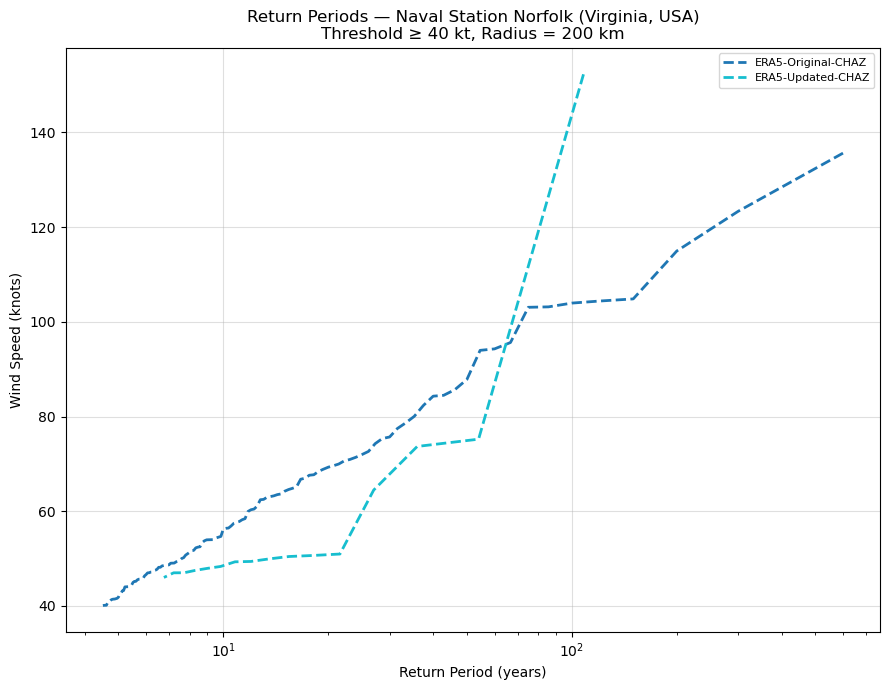

Observed file not found in /home/skramer/DOD/IBTrACS for key: Naval_Air_Station_Oceana___Dam_Neck_Annex__Virginia__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Air_Station_Oceana___Dam_Neck_Annex__Virginia__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Air_Station_Oceana___Dam_Neck_Annex__Virginia__USA_.npz


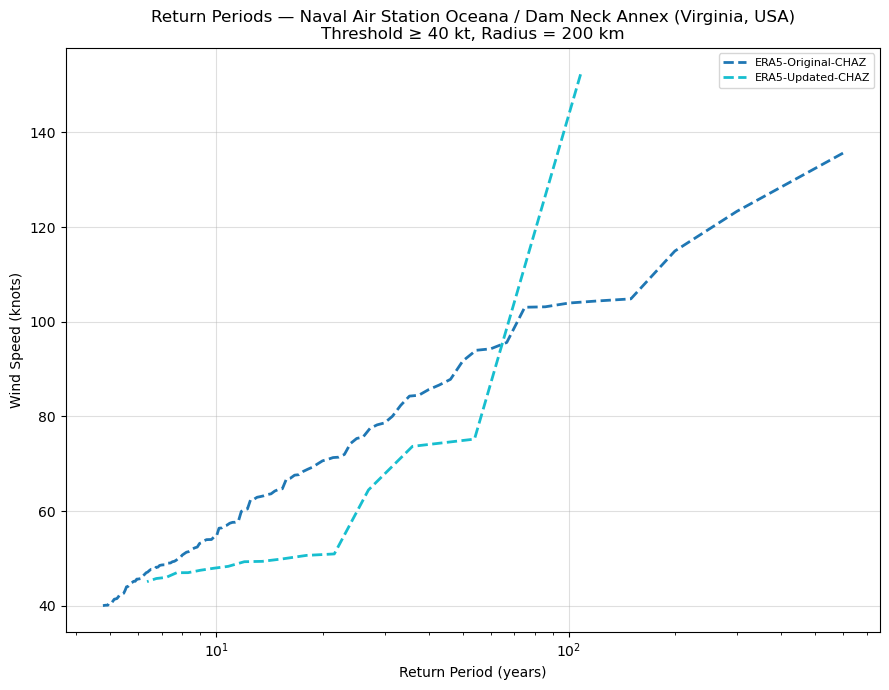

Observed file not found in /home/skramer/DOD/IBTrACS for key: Naval_Construction_Battalion_Center_Gulfport__Mississippi__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Construction_Battalion_Center_Gulfport__Mississippi__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Construction_Battalion_Center_Gulfport__Mississippi__USA_.npz


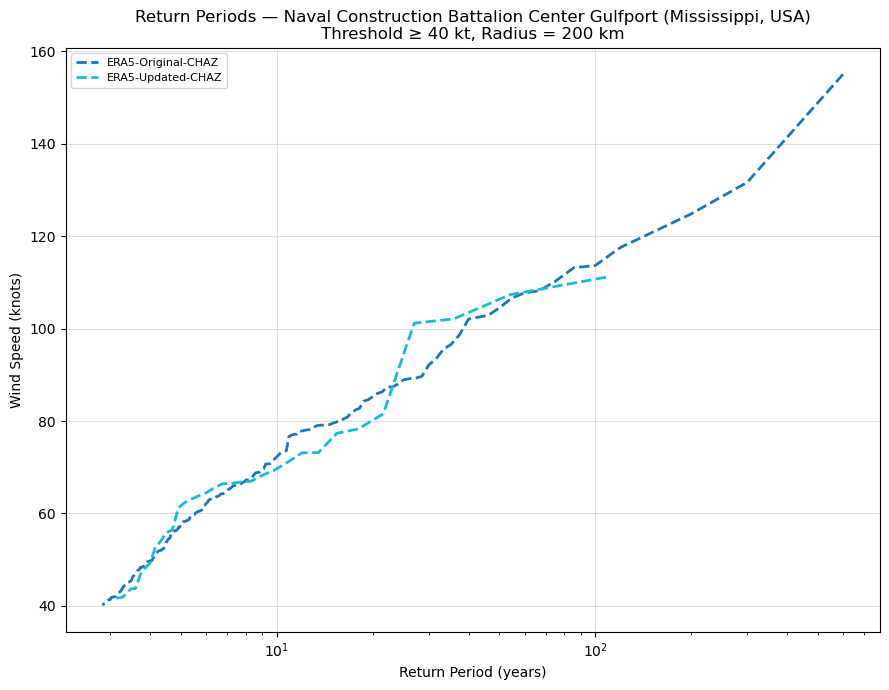

Observed file not found in /home/skramer/DOD/IBTrACS for key: Keesler_Air_Force_Base__Mississippi__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Keesler_Air_Force_Base__Mississippi__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Keesler_Air_Force_Base__Mississippi__USA_.npz


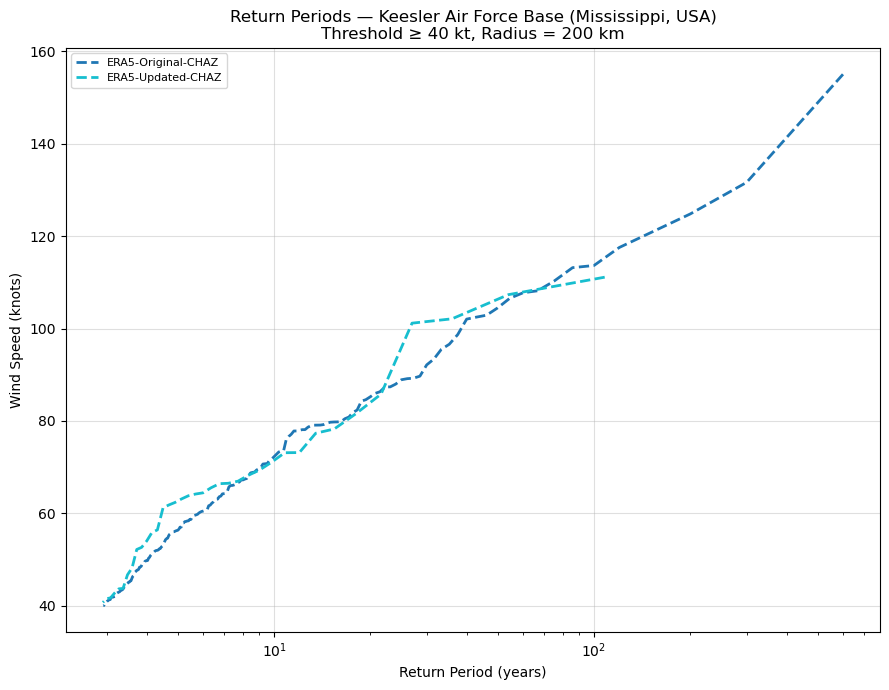

Observed file not found in /home/skramer/DOD/IBTrACS for key: Naval_Air_Station_Key_West__Florida__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Air_Station_Key_West__Florida__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Air_Station_Key_West__Florida__USA_.npz


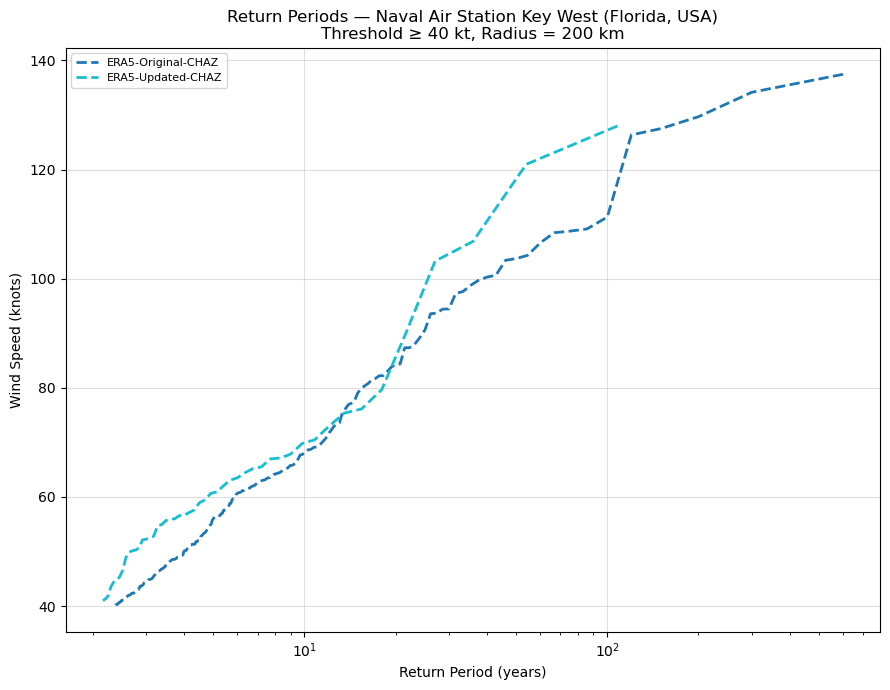

Observed file not found in /home/skramer/DOD/IBTrACS for key: Tyndall_Air_Force_Base__Florida__USA_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Tyndall_Air_Force_Base__Florida__USA_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Tyndall_Air_Force_Base__Florida__USA_.npz


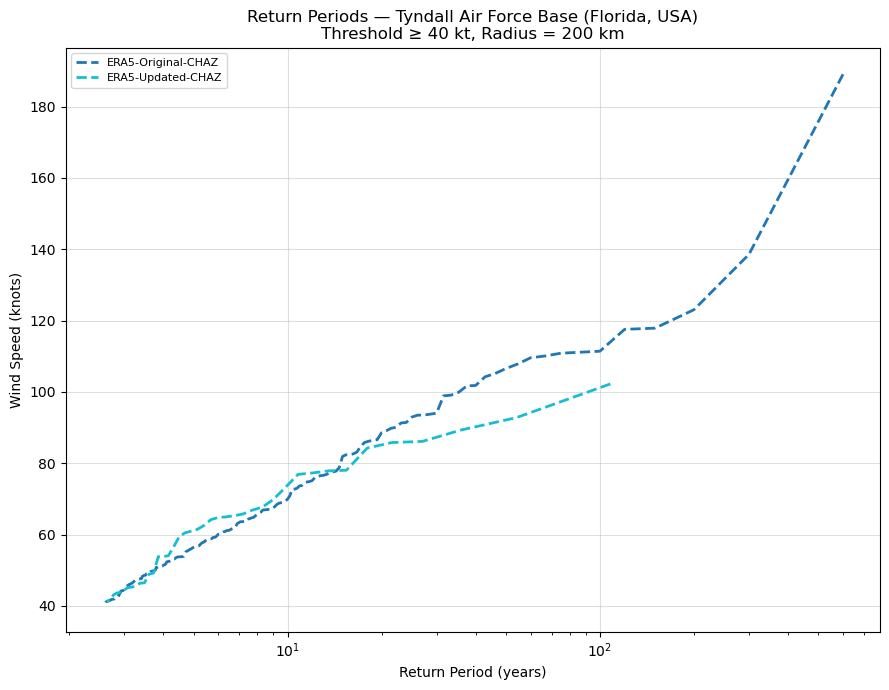

Observed file not found in /home/skramer/DOD/IBTrACS for key: Naval_Base_Guam__Apra_Harbor__Guam_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Base_Guam__Apra_Harbor__Guam_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Naval_Base_Guam__Apra_Harbor__Guam_.npz


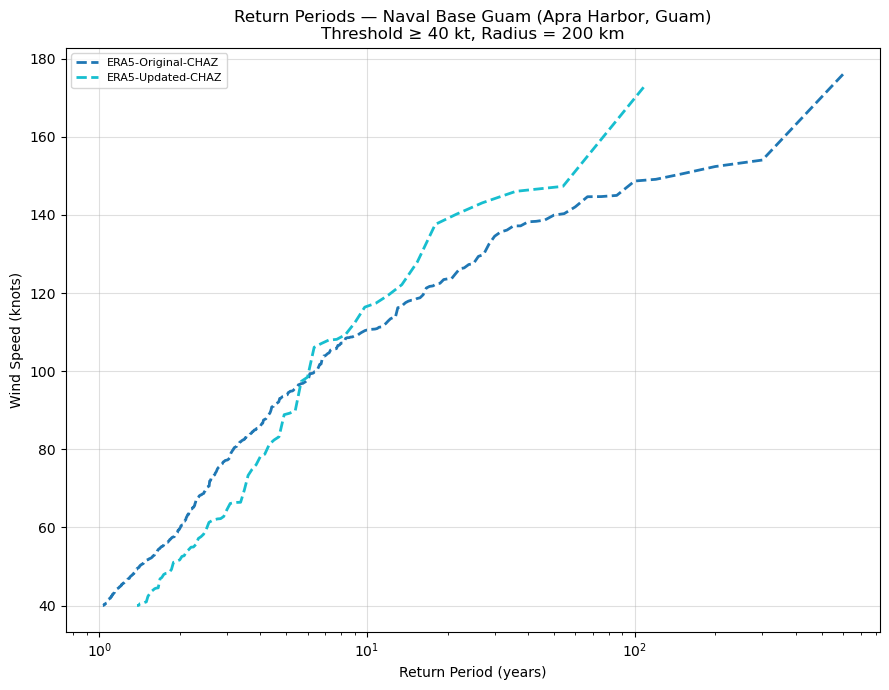

Observed file not found in /home/skramer/DOD/IBTrACS for key: Andersen_Air_Force_Base__Guam_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Andersen_Air_Force_Base__Guam_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Andersen_Air_Force_Base__Guam_.npz


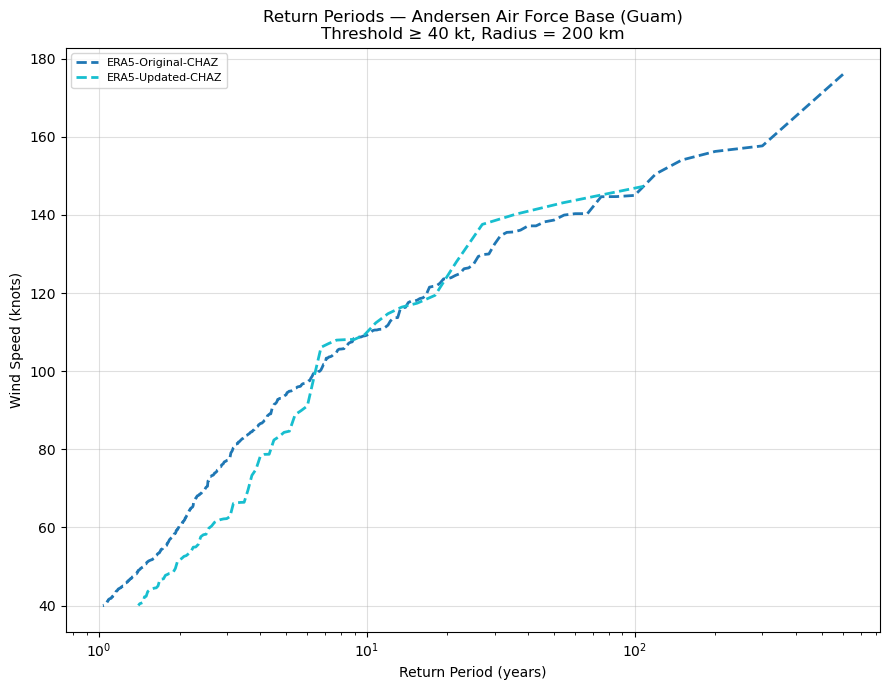

Observed file not found in /home/skramer/DOD/IBTrACS for key: Camp_Smedley_D__Butler__Okinawa__Japan_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Camp_Smedley_D__Butler__Okinawa__Japan_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Camp_Smedley_D__Butler__Okinawa__Japan_.npz


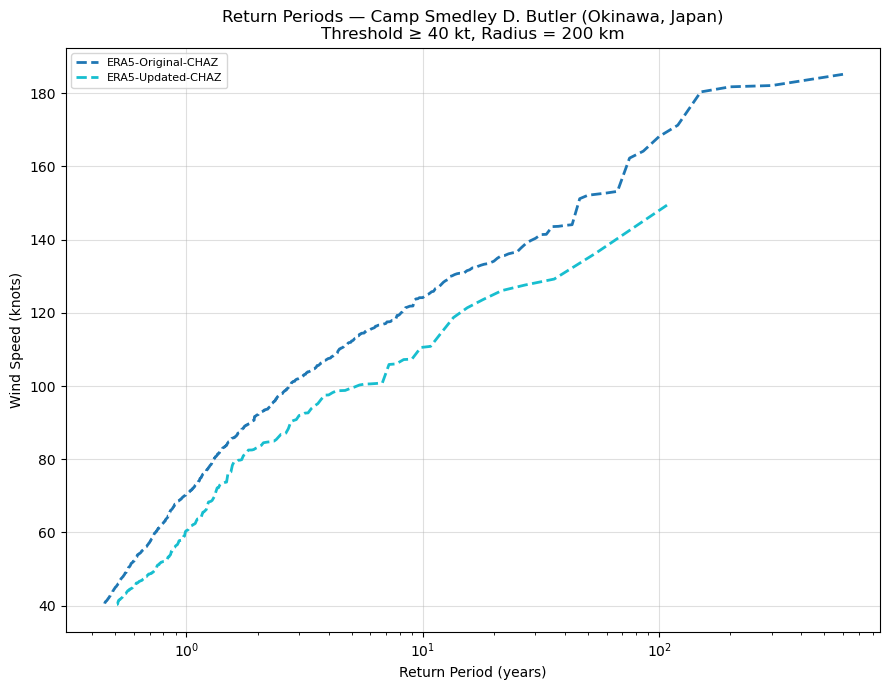

Observed file not found in /home/skramer/DOD/IBTrACS for key: Kadena_Air_Base__Okinawa__Japan_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Kadena_Air_Base__Okinawa__Japan_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Kadena_Air_Base__Okinawa__Japan_.npz


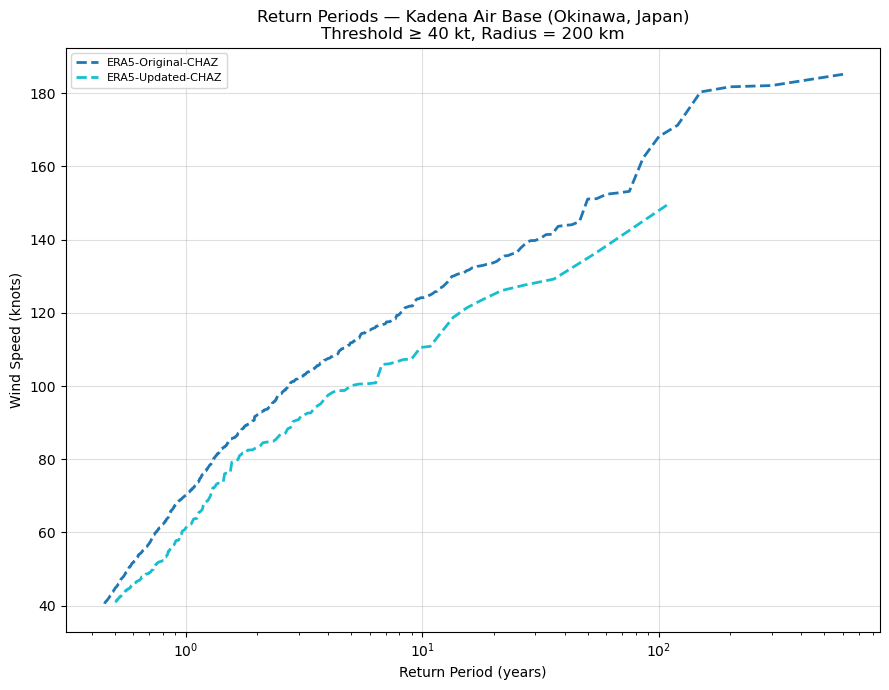

Observed file not found in /home/skramer/DOD/IBTrACS for key: Camp_Schwab__Okinawa__Japan_
Saved ERA5-Original-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Camp_Schwab__Okinawa__Japan_.npz
Saved ERA5-Updated-CHAZ results to output/ReturnPeriods/return_period_curves_ERA5_Camp_Schwab__Okinawa__Japan_.npz


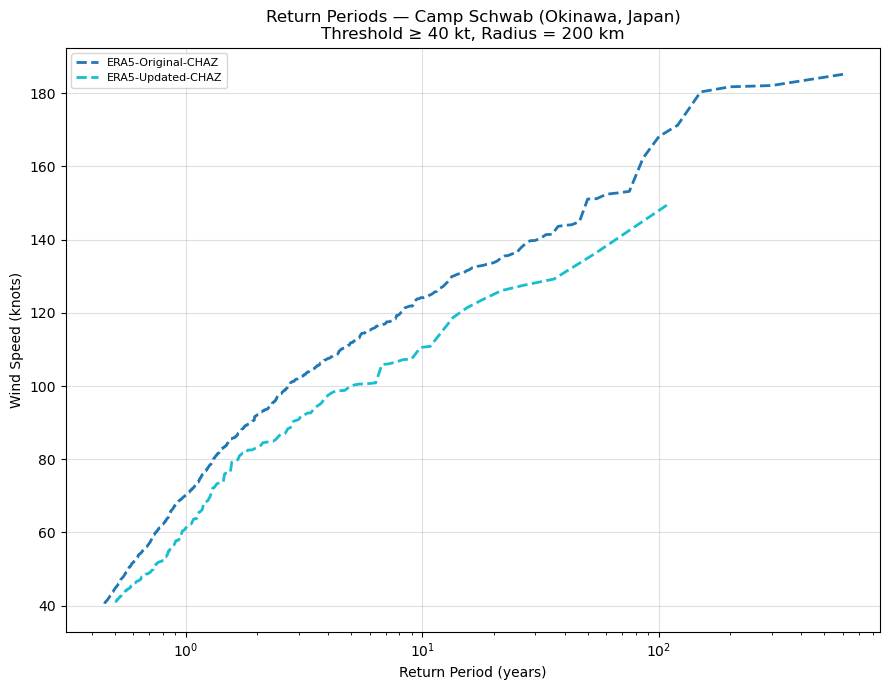

In [3]:
# Run all bases for ERA5 + ERA-Interim
bases = dod_boi.keys()
#bases = ["Naval Base Guam (Apra Harbor, Guam)"]
         # or a subset if you prefer
models = ["ERA5-Original-CHAZ", "ERA5-Updated-CHAZ"]
radius_km = 200                        # <- set your analysis radius
threshold_knots = 40                   # <- calibration threshold

for base in bases:
    plot_return_periods_and_foe(
        models_to_plot=models,
        base_name=base,
        radius_km=radius_km,
        threshold_knots=threshold_knots
    )




In [4]:
dod_boi.keys()

dict_keys(['Naval Station Norfolk (Virginia, USA)', 'Naval Air Station Oceana / Dam Neck Annex (Virginia, USA)', 'Naval Construction Battalion Center Gulfport (Mississippi, USA)', 'Keesler Air Force Base (Mississippi, USA)', 'Naval Air Station Key West (Florida, USA)', 'Tyndall Air Force Base (Florida, USA)', 'Naval Base Guam (Apra Harbor, Guam)', 'Andersen Air Force Base (Guam)', 'Camp Smedley D. Butler (Okinawa, Japan)', 'Kadena Air Base (Okinawa, Japan)', 'Camp Schwab (Okinawa, Japan)'])